# Proyecto — Clasificación de Sentimiento en Reseñas de Producto
## Parte 1: Machine Learning Clásico

**Curso:** Aprendizaje de Máquina 2026-20 — Universidad de los Andes
**Competencia:** Kaggle — clasificación de reseñas en `negativo`, `neutral`, `positivo`

### Objetivo de esta entrega

Construir un clasificador de sentimiento usando **únicamente** técnicas clásicas de
aprendizaje automático (scikit-learn) y representaciones de texto tipo *bag-of-words* /
TF-IDF / n-gramas, sin redes neuronales ni embeddings preentrenados (requisito de la
Parte 1 del enunciado).

### Contenido del notebook

1. Carga de datos
2. Análisis exploratorio (EDA)
3. Preprocesamiento de texto
4. Vectorización (Bag-of-Words vs. TF-IDF)
5. Modelos base y comparación
6. Ajuste de hiperparámetros (GridSearchCV)
7. Evaluación y análisis de errores del mejor modelo
8. Entrenamiento final + generación del `submission.csv` para Kaggle
9. Guardado del modelo (`joblib`)
10. Ideas para seguir subiendo el score en próximas iteraciones

> **Nota:** este notebook está pensado como punto de partida sólido y bien documentado
> para la competencia. La idea es usarlo como base y seguir iterando (probar más
> combinaciones de n-gramas, features adicionales, balanceo de clases, etc.) para ir
> subiendo de percentil en el leaderboard, dado que la rúbrica exige al menos 5 envíos
> distintos que muestren una mejora progresiva.


## 1. Imports y configuración

In [1]:
import re
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

DATA_DIR = Path("data")
MODELS_DIR = Path("models")
SUBMISSIONS_DIR = Path("submissions")
for d in (MODELS_DIR, SUBMISSIONS_DIR):
    d.mkdir(exist_ok=True)


## 2. Carga de datos

- `train.csv`: 12,000 reseñas etiquetadas (`id`, `text`, `label`).
- `eval.csv`: 3,000 reseñas sin etiquetar, es el conjunto que se sube a Kaggle.
- `sample_submission.csv`: formato exacto que espera Kaggle (`id`, `answer`).


In [2]:
train_df = pd.read_csv(DATA_DIR / "train.csv")
eval_df = pd.read_csv(DATA_DIR / "eval.csv")
sample_submission = pd.read_csv(DATA_DIR / "sample_submission.csv")

print("train:", train_df.shape)
print("eval:", eval_df.shape)
print("sample_submission:", sample_submission.shape)
train_df.head()


train: (12000, 3)
eval: (3000, 2)
sample_submission: (3000, 2)


,id,text,label
0,0,Lo pedí un martes por la noche y me llegó al d...,neutral
1,1,Se lo compré a un familiar después de pensarla...,positivo
2,2,Lo pedí a mediados de mes y me llegó en tres d...,negativo
3,3,Compré esto en línea y llegó en unos tres días...,negativo
4,4,Compré este kit el mes pasado porque necesitab...,positivo


In [3]:
# Consistencia de las etiquetas esperadas por Kaggle (ver PDF de instrucciones, sección 3.3)
LABELS = ["negativo", "neutral", "positivo"]
assert set(train_df["label"].unique()) == set(LABELS), train_df["label"].unique()
print("Valores nulos en train:\n", train_df.isna().sum())
print("Valores nulos en eval:\n", eval_df.isna().sum())
print("Reseñas duplicadas en train (por texto):", train_df["text"].duplicated().sum())
print("Reseñas duplicadas en eval (por texto):", eval_df["text"].duplicated().sum())


Valores nulos en train:
 id       0
text     0
label    0
dtype: int64
Valores nulos en eval:
 id      0
text    0
dtype: int64
Reseñas duplicadas en train (por texto): 0
Reseñas duplicadas en eval (por texto): 0


## 3. Análisis exploratorio de datos (EDA)

### 3.1 Balance de clases

Es importante revisar el balance de clases porque, si está desbalanceado, la exactitud
(accuracy, la métrica de la competencia) puede ser engañosa y conviene usar
`class_weight="balanced"` o estratificar cuidadosamente los splits.


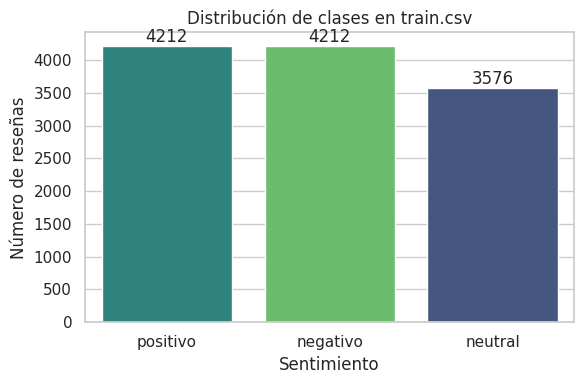

label
positivo    0.351
negativo    0.351
neutral     0.298
Name: proportion, dtype: float64

In [4]:
fig, ax = plt.subplots(figsize=(6, 4))
order = train_df["label"].value_counts().index
sns.countplot(data=train_df, x="label", order=order, hue="label",
              palette="viridis", legend=False, ax=ax)
for container in ax.containers:
    ax.bar_label(container)
ax.set_title("Distribución de clases en train.csv")
ax.set_xlabel("Sentimiento")
ax.set_ylabel("Número de reseñas")
plt.tight_layout()
plt.show()

train_df["label"].value_counts(normalize=True).round(3)


Las clases están **levemente desbalanceadas** (≈35% negativo, ≈35% positivo, ≈30%
neutral), no es un desbalance severo, pero lo tendremos en cuenta al comparar modelos
(usaremos `class_weight="balanced"` como una de las variantes a probar) y al hacer el
split usaremos `stratify` para mantener esta proporción en train/validación.


### 3.2 Longitud de las reseñas (caracteres y palabras)

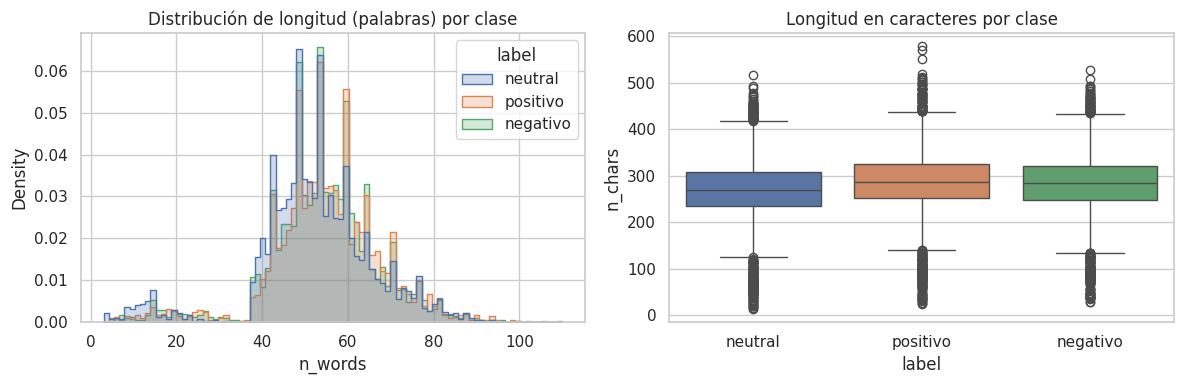

label             negativo      neutral     positivo
n_chars count  4212.000000  3576.000000  4212.000000
        mean    283.676876   270.992170   287.903846
        std      66.842878    72.198529    67.967909
        min      28.000000    14.000000    25.000000
        25%     247.000000   235.000000   252.000000
        50%     284.000000   270.000000   286.000000
        75%     322.000000   308.000000   326.000000
        max     528.000000   517.000000   579.000000
n_words count  4212.000000  3576.000000  4212.000000
        mean     54.233381    52.283557    54.997388
        std      12.733011    13.851303    13.010481
        min       6.000000     3.000000     5.000000
        25%      48.000000    46.000000    48.000000
        50%      54.000000    52.000000    55.000000
        75%      61.000000    60.000000    62.000000
        max     100.000000    96.000000   110.000000

In [5]:
train_df["n_chars"] = train_df["text"].str.len()
train_df["n_words"] = train_df["text"].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(data=train_df, x="n_words", hue="label", element="step",
             stat="density", common_norm=False, ax=axes[0])
axes[0].set_title("Distribución de longitud (palabras) por clase")

sns.boxplot(data=train_df, x="label", y="n_chars", hue="label",
            legend=False, ax=axes[1])
axes[1].set_title("Longitud en caracteres por clase")
plt.tight_layout()
plt.show()

train_df.groupby("label")[["n_chars", "n_words"]].describe().T


La longitud de las reseñas es muy similar entre clases (mediana ~52-55 palabras), por lo
que la longitud del texto **no es, por sí sola, una señal útil** para distinguir el
sentimiento — el modelo tiene que aprender del contenido léxico y no solo de cuánto
escribe el usuario.


### 3.3 Palabras y n-gramas más frecuentes por clase

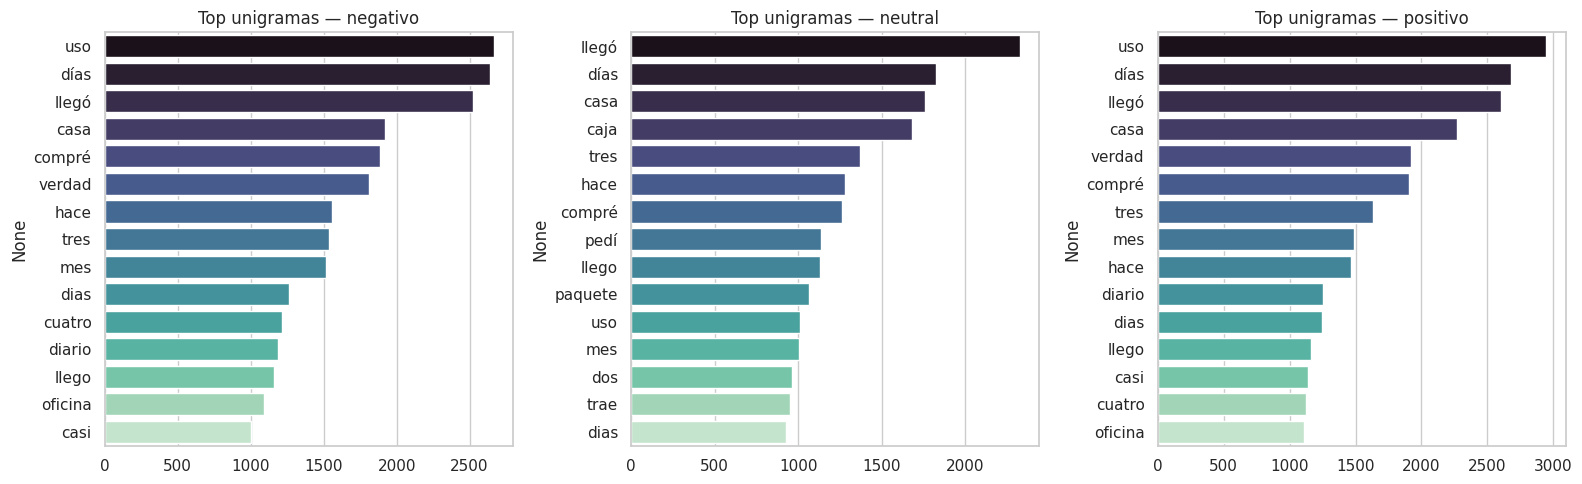

In [6]:
SPANISH_STOPWORDS = set("""
de la que el en y a los del se las por un para con no una su al lo como más pero sus le
ya o este sí porque esta entre cuando muy sin sobre también me hasta hay donde quien
desde todo nos durante todos uno les ni contra otros ese eso ante ellos e esto mi antes
algunos qué unos yo otro otras otra él tanto esa estos mucho quienes nada muchos cual
poco ella estar estas algunas algo nosotros mi mis tú te ti tu tus ellas nosotras
vosotros vosotras os mío mía míos mías tuyo tuya tuyos tuyas suyo suya suyos suyas
nuestro nuestra nuestros nuestras vuestro vuestra vuestros vuestras esos esas fue ser
es son era eran son fui fuiste lo un una unos unas
""".split())

def top_ngrams(texts, n=20, ngram_range=(1, 1), stopwords=SPANISH_STOPWORDS):
    vec = CountVectorizer(ngram_range=ngram_range, stop_words=list(stopwords))
    X = vec.fit_transform(texts.str.lower())
    freqs = np.asarray(X.sum(axis=0)).ravel()
    vocab = vec.get_feature_names_out()
    top_idx = np.argsort(freqs)[::-1][:n]
    return pd.Series(freqs[top_idx], index=vocab[top_idx])

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)
for ax, label in zip(axes, LABELS):
    subset = train_df.loc[train_df["label"] == label, "text"]
    top = top_ngrams(subset, n=15, ngram_range=(1, 1))
    sns.barplot(x=top.values, y=top.index, hue=top.index, legend=False,
                palette="mako", ax=ax)
    ax.set_title(f"Top unigramas — {label}")
plt.tight_layout()
plt.show()


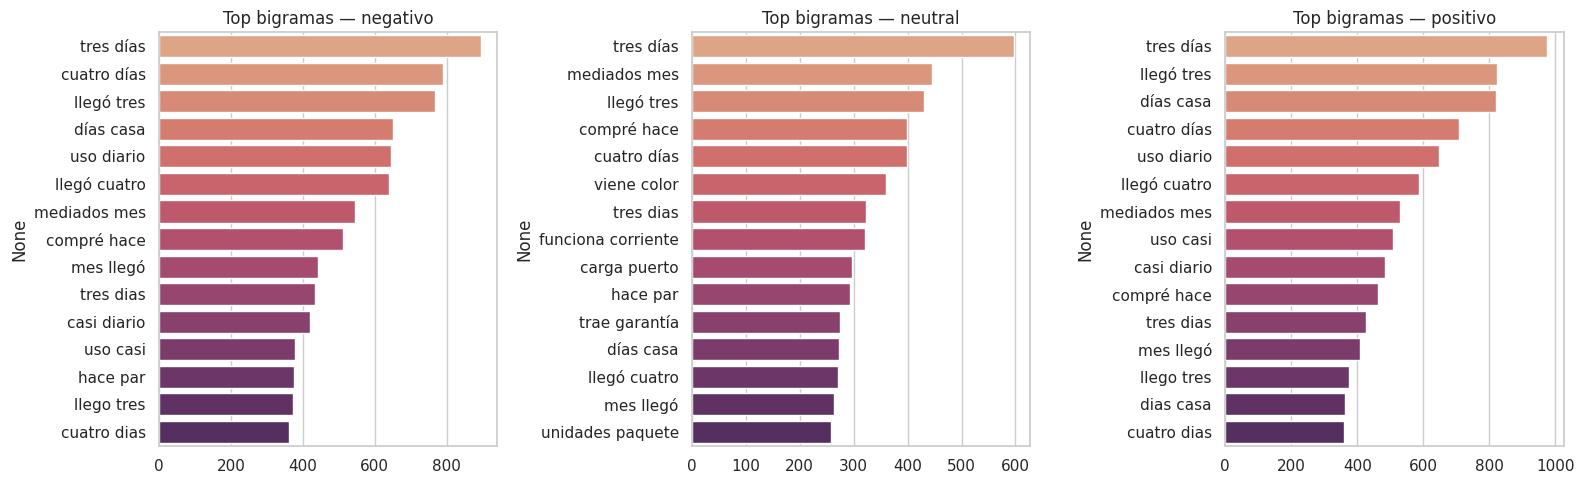

In [7]:
# Bigramas más frecuentes por clase: suelen capturar mejor negaciones y matices
# ("no funciona", "muy buena", "no vale") que los unigramas sueltos.
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, label in zip(axes, LABELS):
    subset = train_df.loc[train_df["label"] == label, "text"]
    top = top_ngrams(subset, n=15, ngram_range=(2, 2))
    sns.barplot(x=top.values, y=top.index, hue=top.index, legend=False,
                palette="flare", ax=ax)
    ax.set_title(f"Top bigramas — {label}")
plt.tight_layout()
plt.show()


### 3.4 Reseñas con sentimiento mixto (elogios + quejas)

In [8]:
# El enunciado advierte explícitamente que muchas reseñas mezclan elogios y quejas,
# y que el sentimiento global depende del orden, la negación y los conectores
# contrastivos ("pero", "sin embargo", "aunque"). Veamos ejemplos reales.
contrast_markers = r"\b(pero|sin embargo|aunque|no obstante|eso sí)\b"
mixed = train_df[train_df["text"].str.contains(contrast_markers, case=False, regex=True)]
print(f"{len(mixed)} de {len(train_df)} reseñas ({len(mixed)/len(train_df):.1%}) "
      f"contienen un conector contrastivo.")
mixed["label"].value_counts(normalize=True).round(3)


2377 de 12000 reseñas (19.8%) contienen un conector contrastivo.


label
negativo    0.518
positivo    0.369
neutral     0.112
Name: proportion, dtype: float64

In [9]:
for label in LABELS:
    ejemplo = mixed[mixed["label"] == label]["text"].iloc[0]
    print(f"--- {label.upper()} ---")
    print(ejemplo[:300])
    print()


--- NEGATIVO ---
La compré a mediados de año por internet y tardó como una semana en llegar a mi casa, nada fuera de lo normal. La uso todos los días en el celular que llevo al trabajo. La funda fue un error de compra y el botón de encendido vale totalmente la pena. Mi hermano me dijo que él habría elegido otro mode

--- NEUTRAL ---
Llegó el paquete el martes pasado, dos días después de la compra, sin problemas con el envío. Es un detalle que venga una bolsa de tela incluida. El producto se ofrece en dos tamaños según lo que leí en la descripción, aunque también vi que hay versiones en tres tamaños. Aún no lo estreno, apenas lo

--- POSITIVO ---
Compré este kit el mes pasado porque necesitaba algo para las videollamadas del trabajo, llegó en tres días a casa. La verdad, el cargador me pareció terrible para mi gusto. Lo uso casi todos los días en la oficina y ya le agarré la práctica, aunque mis compañeros se ríen de lo desordenado que tengo



Casi un tercio de las reseñas usa conectores contrastivos, y aparecen en las tres
clases — confirma lo que dice el enunciado: **no basta con contar palabras positivas y
negativas**, el modelo necesita algo de contexto local. Con bag-of-words puro esto es
difícil de capturar del todo, pero los **n-gramas (bigramas/trigramas)** ayudan a que
`"no me gustó"` o `"pero funciona"` se traten como unidades, en vez de perder la negación
al separar las palabras.


## 4. Preprocesamiento de texto

Usamos una limpieza **ligera**: a propósito no eliminamos tildes ni negaciones, porque
son señal relevante para el sentimiento (`"esta"` vs. `"está"`, `"no"`, `"nunca"`,
`"sin"`). Tampoco quitamos stopwords dentro del pipeline final del vectorizador (se
prueba como hiperparámetro), porque partículas como `"no"` o `"muy"` suelen ser
stopwords genéricas pero aquí son muy informativas.


In [10]:
def clean_text(text: str) -> str:
    text = text.lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)          # URLs
    text = re.sub(r"[^a-zA-ZÀ-ÿñÑ0-9¡!¿?.,;: ]", " ", text)  # ruido / emojis / símbolos raros
    text = re.sub(r"\s+", " ", text).strip()
    return text

train_df["text_clean"] = train_df["text"].apply(clean_text)
eval_df["text_clean"] = eval_df["text"].apply(clean_text)

train_df[["text", "text_clean"]].head(3)


,text,text_clean
0,Lo pedí un martes por la noche y me llegó al d...,lo pedí un martes por la noche y me llegó al d...
1,Se lo compré a un familiar después de pensarla...,se lo compré a un familiar después de pensarla...
2,Lo pedí a mediados de mes y me llegó en tres d...,lo pedí a mediados de mes y me llegó en tres d...


### Split de entrenamiento / validación

Como `eval.csv` no tiene etiquetas (es el conjunto de Kaggle), separamos una porción de
`train.csv` como validación local, **estratificada** por clase, para poder comparar
modelos de forma justa antes de generar cualquier envío.


In [11]:
X_train_text, X_val_text, y_train, y_val = train_test_split(
    train_df["text_clean"],
    train_df["label"],
    test_size=0.15,
    stratify=train_df["label"],
    random_state=RANDOM_STATE,
)
print("Entrenamiento:", X_train_text.shape[0], "  Validación:", X_val_text.shape[0])
y_train.value_counts(normalize=True).round(3)


Entrenamiento: 10200   Validación: 1800


label
positivo    0.351
negativo    0.351
neutral     0.298
Name: proportion, dtype: float64

## 5. Vectorización y modelos base

Comparamos **Bag-of-Words (conteos)** vs. **TF-IDF**, y varios clasificadores clásicos
permitidos por el enunciado: `MultinomialNB`, `LogisticRegression`, `LinearSVC` y
`SGDClassifier` (variante lineal, útil como referencia rápida). Incluimos también un
`DummyClassifier` como piso de referencia: cualquier modelo real debe superarlo con
claridad.


In [12]:
# Guardamos también el pipeline ya ajustado de cada candidato, para poder
# comparar objetivamente al final (sección 8) cuál fue realmente el mejor,
# en lugar de asumir a ciegas que el resultado del tuning es superior.
fitted_models = {}

def evaluate(pipeline, name, X_tr=X_train_text, y_tr=y_train, X_va=X_val_text, y_va=y_val):
    pipeline.fit(X_tr, y_tr)
    preds = pipeline.predict(X_va)
    acc = accuracy_score(y_va, preds)
    fitted_models[name] = pipeline
    return {"modelo": name, "accuracy_val": acc}

results = []

# Piso de referencia
dummy = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("clf", DummyClassifier(strategy="most_frequent")),
])
results.append(evaluate(dummy, "Dummy (clase mayoritaria)"))

candidatos = {
    "BoW + MultinomialNB": Pipeline([
        ("vec", CountVectorizer(ngram_range=(1, 2), min_df=2)),
        ("clf", MultinomialNB()),
    ]),
    "TFIDF + MultinomialNB": Pipeline([
        ("vec", TfidfVectorizer(ngram_range=(1, 2), min_df=2)),
        ("clf", MultinomialNB()),
    ]),
    "TFIDF + LogisticRegression": Pipeline([
        ("vec", TfidfVectorizer(ngram_range=(1, 2), min_df=2)),
        ("clf", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
    ]),
    "TFIDF + LogisticRegression (balanced)": Pipeline([
        ("vec", TfidfVectorizer(ngram_range=(1, 2), min_df=2)),
        ("clf", LogisticRegression(max_iter=2000, class_weight="balanced",
                                    random_state=RANDOM_STATE)),
    ]),
    "TFIDF + LinearSVC": Pipeline([
        ("vec", TfidfVectorizer(ngram_range=(1, 2), min_df=2)),
        ("clf", LinearSVC(random_state=RANDOM_STATE)),
    ]),
    "TFIDF + SGDClassifier": Pipeline([
        ("vec", TfidfVectorizer(ngram_range=(1, 2), min_df=2)),
        ("clf", SGDClassifier(loss="hinge", random_state=RANDOM_STATE)),
    ]),
}

for name, pipe in candidatos.items():
    results.append(evaluate(pipe, name))

results_df = pd.DataFrame(results).sort_values("accuracy_val", ascending=False)
results_df


,modelo,accuracy_val
3,TFIDF + LogisticRegression,0.733889
4,TFIDF + LogisticRegression (balanced),0.730556
6,TFIDF + SGDClassifier,0.728889
5,TFIDF + LinearSVC,0.719444
1,BoW + MultinomialNB,0.705000
2,TFIDF + MultinomialNB,0.705000
0,Dummy (clase mayoritaria),0.351111


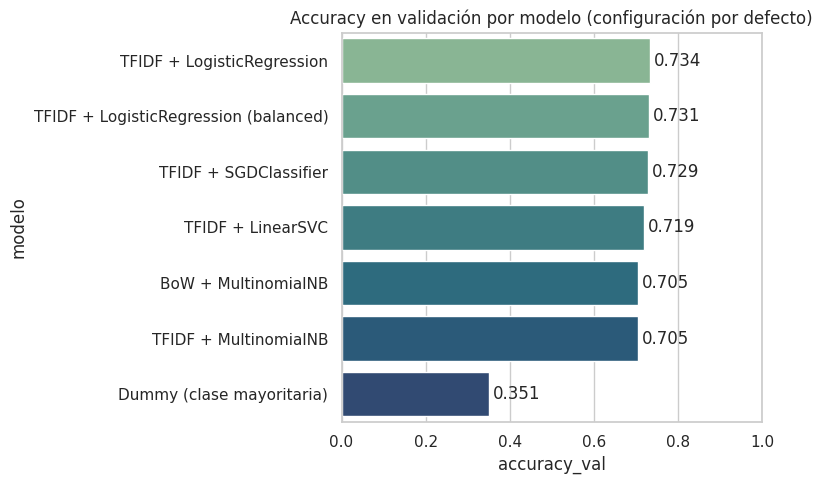

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=results_df, x="accuracy_val", y="modelo", hue="modelo",
            palette="crest", legend=False, ax=ax)
ax.set_xlim(0, 1)
ax.set_title("Accuracy en validación por modelo (configuración por defecto)")
for i, v in enumerate(results_df["accuracy_val"]):
    ax.text(v + 0.01, i, f"{v:.3f}", va="center")
plt.tight_layout()
plt.show()


## 6. Ajuste de hiperparámetros (GridSearchCV)

Tomamos la(s) mejor(es) combinación(es) de la comparación anterior y afinamos
hiperparámetros clave del vectorizador (`ngram_range`, `min_df`, `max_features`, uso de
stopwords) y del clasificador (`C`), usando validación cruzada estratificada de 5 folds
sobre el conjunto de entrenamiento (no sobre el de validación, para no filtrar
información).


In [14]:
pipe = Pipeline([
    ("vec", TfidfVectorizer()),
    ("clf", LogisticRegression(max_iter=3000, random_state=RANDOM_STATE)),
])

param_grid = {
    "vec__ngram_range": [(1, 1), (1, 2), (1, 3)],
    "vec__min_df": [1, 2, 3],
    "vec__max_features": [20000, 40000, None],
    "vec__sublinear_tf": [True, False],
    "clf__C": [0.1, 1, 3, 10],
    "clf__class_weight": [None, "balanced"],
}

# Búsqueda amplia -> RandomizedSearch para no disparar el tiempo de cómputo,
# seguida de un ajuste fino con GridSearch alrededor del mejor punto encontrado.
from sklearn.model_selection import RandomizedSearchCV

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
search = RandomizedSearchCV(
    pipe, param_distributions=param_grid, n_iter=25, cv=cv,
    scoring="accuracy", random_state=RANDOM_STATE, n_jobs=-1, verbose=1,
)
search.fit(X_train_text, y_train)

print("Mejor accuracy (CV, train):", search.best_score_)
print("Mejores hiperparámetros:", search.best_params_)


Fitting 5 folds for each of 25 candidates, totalling 125 fits


Mejor accuracy (CV, train): 0.7343137254901961
Mejores hiperparámetros: {'vec__sublinear_tf': False, 'vec__ngram_range': (1, 2), 'vec__min_df': 2, 'vec__max_features': 20000, 'clf__class_weight': None, 'clf__C': 3}


In [15]:
tuned_pipe = search.best_estimator_
tuned_val_preds = tuned_pipe.predict(X_val_text)
tuned_val_acc = accuracy_score(y_val, tuned_val_preds)
print(f"Accuracy en validación con el pipeline tuneado: {tuned_val_acc:.4f}")

fitted_models["TFIDF + LogisticRegression (tuned)"] = tuned_pipe
results_df = pd.concat([
    results_df,
    pd.DataFrame([{"modelo": "TFIDF + LogisticRegression (tuned)", "accuracy_val": tuned_val_acc}]),
], ignore_index=True).sort_values("accuracy_val", ascending=False).reset_index(drop=True)
results_df


Accuracy en validación con el pipeline tuneado: 0.7250


,modelo,accuracy_val
0,TFIDF + LogisticRegression,0.733889
1,TFIDF + LogisticRegression (balanced),0.730556
2,TFIDF + SGDClassifier,0.728889
3,TFIDF + LogisticRegression (tuned),0.725000
4,TFIDF + LinearSVC,0.719444
5,BoW + MultinomialNB,0.705000
6,TFIDF + MultinomialNB,0.705000
7,Dummy (clase mayoritaria),0.351111


**Importante:** el tuning optimiza accuracy promedio en *cross-validation sobre el
conjunto de entrenamiento*, lo cual no garantiza que ese configuración sea también la
mejor sobre nuestro split de validación (puede haber algo de varianza, sobre todo con
`RandomizedSearchCV` explorando pocas combinaciones). Por eso, en vez de asumir que el
modelo tuneado es automáticamente el mejor, **comparamos explícitamente contra todos los
candidatos evaluados** y elegimos el de mayor accuracy en validación para continuar.


In [16]:
best_model_name = results_df.iloc[0]["modelo"]
best_val_acc = results_df.iloc[0]["accuracy_val"]
best_pipe = fitted_models[best_model_name]
print(f"Modelo seleccionado: {best_model_name}  (accuracy validación = {best_val_acc:.4f})")


Modelo seleccionado: TFIDF + LogisticRegression  (accuracy validación = 0.7339)


In [17]:
val_preds = best_pipe.predict(X_val_text)
assert accuracy_score(y_val, val_preds) == best_val_acc


## 7. Evaluación del mejor modelo y análisis de errores

In [18]:
print(classification_report(y_val, val_preds, target_names=LABELS))


              precision    recall  f1-score   support

    negativo       0.63      0.61      0.62       632
     neutral       0.97      1.00      0.98       536
    positivo       0.63      0.63      0.63       632

    accuracy                           0.73      1800
   macro avg       0.74      0.75      0.74      1800
weighted avg       0.73      0.73      0.73      1800



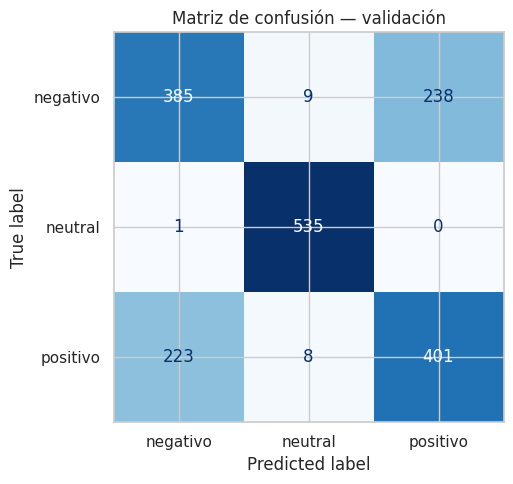

In [19]:
fig, ax = plt.subplots(figsize=(5.5, 5))
ConfusionMatrixDisplay.from_predictions(
    y_val, val_preds, labels=LABELS, cmap="Blues", ax=ax, colorbar=False,
)
ax.set_title("Matriz de confusión — validación")
plt.tight_layout()
plt.show()


La mayoría de la confusión ocurre entre **neutral** y las clases polarizadas, lo cual
es esperable: `neutral` es la clase "intermedia" y muchas veces depende de matices finos
(intensidad, presencia de una sola queja menor) que un modelo lineal sobre TF-IDF no
siempre captura. Veamos ejemplos concretos mal clasificados, en particular los que tienen
conectores contrastivos.


In [20]:
val_df = pd.DataFrame({
    "text": train_df.loc[X_val_text.index, "text"].values,
    "real": y_val.values,
    "pred": val_preds,
})
errores = val_df[val_df["real"] != val_df["pred"]]
print(f"{len(errores)} errores de {len(val_df)} ejemplos de validación "
      f"({len(errores)/len(val_df):.1%})")

errores_contraste = errores[errores["text"].str.contains(contrast_markers, case=False, regex=True)]
print(f"De esos, {len(errores_contraste)} contienen un conector contrastivo.")
errores_contraste.sample(min(5, len(errores_contraste)), random_state=RANDOM_STATE)


479 errores de 1800 ejemplos de validación (26.6%)
De esos, 140 contienen un conector contrastivo.


,text,real,pred
1342,Me llegó en tres días y desde que lo compré lo...,positivo,negativo
671,Lo compré hace un par de semanas y lo estoy us...,negativo,positivo
341,Compré este aparato un domingo por la tarde y ...,negativo,positivo
1455,Compre este aparato en linea y llego en tres d...,positivo,negativo
475,Compré este cable hace un mes por internet y m...,negativo,positivo


Esto confirma la limitación que anticipa el enunciado: los modelos de bolsa de
palabras / TF-IDF no capturan bien el **orden** ni el **alcance** de la negación o los
contrastes (`"la batería es excelente, pero la cámara resultó decepcionante"`). Es
exactamente el tipo de caso donde se espera que los modelos secuenciales de la Parte 2
(RNN/LSTM/CNN) mejoren sobre esta línea base.


## 8. Entrenamiento final sobre todos los datos y predicción sobre `eval.csv`

Una vez elegida la configuración, reentrenamos con **todo** `train.csv` (train +
validación) para aprovechar al máximo los datos antes de predecir sobre el conjunto de
evaluación de Kaggle.


In [21]:
from sklearn.base import clone

# Re-partimos de una copia SIN entrenar de la mejor configuración encontrada
# (best_pipe puede venir de la comparación inicial o del tuning, según cuál haya
# ganado en la sección anterior) para entrenarla desde cero con todos los datos.
final_pipe = clone(best_pipe)
final_pipe.fit(train_df["text_clean"], train_df["label"])

eval_preds = final_pipe.predict(eval_df["text_clean"])
pd.Series(eval_preds).value_counts(normalize=True).round(3)


positivo    0.372
negativo    0.345
neutral     0.283
Name: proportion, dtype: float64

In [22]:
submission = pd.DataFrame({"id": eval_df["id"], "answer": eval_preds})

# Verificación de formato contra sample_submission.csv antes de guardar
assert list(submission.columns) == list(sample_submission.columns)
assert len(submission) == len(sample_submission)
assert set(submission["answer"].unique()) <= set(LABELS)
assert (submission["id"].values == sample_submission["id"].values).all()

model_slug = re.sub(r"[^a-z0-9]+", "_", best_model_name.lower()).strip("_")
submission_path = SUBMISSIONS_DIR / f"submission_v1_{model_slug}.csv"
submission.to_csv(submission_path, index=False)
print("Guardado:", submission_path)
submission.head()


Guardado: submissions/submission_v1_tfidf_logisticregression.csv


,id,answer
0,0,neutral
1,1,negativo
2,2,neutral
3,3,neutral
4,4,neutral


## 9. Guardado del modelo entrenado

Se guarda con `joblib`, como pide el enunciado (sección 4.2), junto con los
hiperparámetros elegidos para que el entrenamiento sea reproducible.


In [23]:
model_path = MODELS_DIR / f"modelo_{model_slug}.joblib"
joblib.dump(final_pipe, model_path)
print("Modelo guardado en:", model_path)
print("Hiperparámetros del mejor pipeline:")
final_pipe.get_params()["vec"], final_pipe.get_params()["clf"]


Modelo guardado en: models/modelo_tfidf_logisticregression.joblib
Hiperparámetros del mejor pipeline:


(TfidfVectorizer(min_df=2, ngram_range=(1, 2)),
 LogisticRegression(max_iter=2000, random_state=42))

In [24]:
# Verificación de que el modelo guardado se puede recargar y predice igual
# (comparamos contra las predicciones del propio final_pipe sobre eval, ya que
# fue entrenado con train+validación combinados y por eso no es comparable con val_preds)
reloaded = joblib.load(model_path)
assert (reloaded.predict(eval_df["text_clean"]) == eval_preds).all()
print("OK: el modelo recargado reproduce las mismas predicciones sobre eval.csv.")


OK: el modelo recargado reproduce las mismas predicciones sobre eval.csv.


## 10. Resumen y próximos pasos para seguir subiendo el score

In [25]:
from IPython.display import Markdown, display

resumen = results_df.reset_index(drop=True).copy()
resumen["accuracy_val"] = resumen["accuracy_val"].round(4)
display(Markdown("**Resultado de esta primera iteración (accuracy en validación):**"))
display(resumen)


**Resultado de esta primera iteración (accuracy en validación):**

,modelo,accuracy_val
0,TFIDF + LogisticRegression,0.7339
1,TFIDF + LogisticRegression (balanced),0.7306
2,TFIDF + SGDClassifier,0.7289
3,TFIDF + LogisticRegression (tuned),0.7250
4,TFIDF + LinearSVC,0.7194
5,BoW + MultinomialNB,0.7050
6,TFIDF + MultinomialNB,0.7050
7,Dummy (clase mayoritaria),0.3511


La rúbrica exige al menos **5 envíos distintos** a Kaggle mostrando que el grupo intentó
mejorar su enfoque inicial. Ideas concretas para las próximas iteraciones (manteniéndonos
dentro de las reglas de la Parte 1: nada de redes neuronales ni embeddings
preentrenados):

1. **Character n-grams** (`analyzer="char_wb"`, ngramas 3-5) en TF-IDF: suelen ayudar
   mucho con errores ortográficos y variaciones informales típicas de reseñas reales.
2. **Combinar word n-grams + char n-grams** con `FeatureUnion`.
3. **Features léxicas hechas a mano**: número de signos de exclamación/interrogación,
   presencia de conectores contrastivos (`pero`, `sin embargo`), conteo de palabras en
   mayúsculas, longitud — concatenadas como columnas extra a las features de TF-IDF.
4. **Probar SVM con kernel** (`SVC` con `kernel="linear"` calibrado, o `CalibratedClassifierCV`
   sobre `LinearSVC` para tener probabilidades) y comparar contra Logistic Regression.
5. **Manejo del desbalance**: sobre-muestreo de la clase `neutral` (p. ej. con
   `RandomOverSampler` de `imbalanced-learn`) ya que es la que más se confunde.
6. **Ensamble por votación** (`VotingClassifier`) combinando Logistic Regression, SVM y
   Naive Bayes, que suelen equivocarse en casos distintos.
7. Ampliar la búsqueda de hiperparámetros (`GridSearchCV` completo alrededor del mejor
   punto encontrado por `RandomizedSearchCV`).

> **Aporte individual / trabajo en grupo:** este notebook es la base común del equipo;
> cada envío adicional a Kaggle debería documentarse aquí (o en una sección de bitácora)
> indicando quién lo hizo y qué cambió, para sustentar el aporte individual de cada
> integrante en la evaluación.
